In [1]:
%pip install torch
%pip install tqdm
%pip install transformers
%pip install sentencepiece
%pip install protobuf

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
from PIL import Image
from PIL import ImageDraw
from PIL import ImageFont
import matplotlib.pyplot as plt
from matplotlib import font_manager

In [3]:
import unicodedata
import torch
import torch.nn.functional as F
import pandas as pd
import tqdm
from PIL import Image, ImageDraw, ImageFont
from matplotlib import font_manager
from transformers import AutoProcessor, SiglipModel
from sklearn.metrics import roc_auc_score
import os

/Users/valeriexin/IAP_2026_urop/itau_venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Summer 2025

In [43]:
# add font to matplotlib fonts
font_manager.fontManager.addfont('/Users/valeriexin/IAP_2026_urop/font_files/Caveat-Regular.ttf')
font_manager.fontManager.addfont('/Users/valeriexin/IAP_2026_urop/font_files/Pacifico-Regular.ttf')
font_manager.fontManager.addfont('/Users/valeriexin/IAP_2026_urop/font_files/calibri.ttf')
font_manager.fontManager.addfont('/Users/valeriexin/IAP_2026_urop/font_files/DMSans_18pt-Regular.ttf')
font_manager.fontManager.addfont('/Users/valeriexin/IAP_2026_urop/font_files/Kristi-Regular.ttf')

## Tex -> glyph -> embedding

In [56]:
def _get_unicode_font(font_size=14):
    # Try DejaVu Sans (bundled with matplotlib). Fall back to PIL default (not ideal).
    try:
        path = font_manager.findfont("Helvetica", fallback_to_default=True)
        return ImageFont.truetype(path, font_size)
    except Exception:
        return ImageFont.load_default()


def generate_glyph_image(text, image_size=(224, 224)):
    """
    Converts a given business name into a glyph (image representation).
    """
    text = unicodedata.normalize('NFC', text)
    image = Image.new("RGB", image_size, color=(0,0,0))  # "L" mode for grayscale
    draw = ImageDraw.Draw(image)
    font = _get_unicode_font()

    # Get text bounding box
    bbox = draw.textbbox((0, 0), text, font=font)
    text_width = bbox[2] - bbox[0]
    text_height = bbox[3] - bbox[1]
    x = (image_size[0] - text_width) // 2
    y = (image_size[1] - text_height) // 2

    # Draw text onto the image
    draw.text((x, y), text, font=font, fill=(255, 255, 255))

    return image

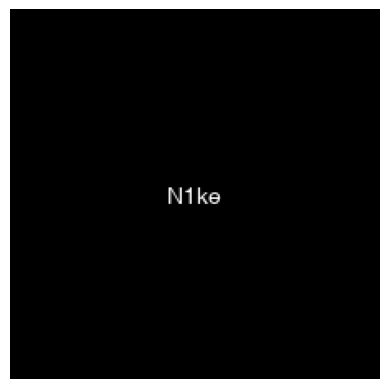

In [57]:
pepper_aussie_pup = generate_glyph_image("N1ke")
plt.imshow(pepper_aussie_pup)
plt.axis("off")
plt.show()

In [58]:
# --- 2) Load model/processor (joint SigLIP; gives projected image_embeds) ---
from transformers import SiglipVisionModel
model = SiglipVisionModel.from_pretrained("google/siglip-base-patch16-224")
processor = AutoProcessor.from_pretrained("google/siglip-base-patch16-224")

In [59]:
from math import ceil
from tqdm.auto import tqdm
import torch
import torch.nn.functional as F

def embed_names(names, batch_size=128):
    # converts names to glyphs then embeddings using the Siglip model; returns dictionary of names and their embeddings
    uniq = sorted(set(map(str, names)))
    name_to_emb = {}

    # pre-render images
    imgs = {}
    it = tqdm(uniq, desc="Rendering glyphs", unit="img")
    for n in it:
        imgs[n] = generate_glyph_image(n)

    num_batches = ceil(len(uniq) / batch_size)
    rng = range(0, len(uniq), batch_size)
    rng = tqdm(rng, total=num_batches, desc="Embedding images", unit="batch", dynamic_ncols=True)

    for i in rng:
        chunk = uniq[i:i + batch_size]
        pil_batch = [imgs[n] for n in chunk]

        batch = processor(images=pil_batch, return_tensors="pt")

        with torch.no_grad():
            out = model(**batch)
            embs = out.pooler_output

        # normalize
        embs = F.normalize(embs, dim=-1)

        for n, e in zip(chunk, embs):
            name_to_emb[n] = e

    return name_to_emb


In [60]:
from math import ceil
from tqdm.auto import tqdm
import torch
import torch.nn.functional as F


In [61]:
# open parquet
test_data = pd.read_parquet('/Users/valeriexin/IAP_2026_urop/Itau-group-2/data/processed/validate_pairs_ref_10k.parquet')
final_df = pd.read_parquet('/Users/valeriexin/IAP_2026_urop/Itau-group-2/data/processed/validate_pairs_ref_10k.parquet')


In [62]:
all_names = pd.concat([test_data["fraudulent_name"], test_data["real_name"]], ignore_index=True)
name2emb = embed_names(all_names.tolist(), batch_size=128)

# --- 4) Vectorized cosine similarities for each pair ---
L = torch.stack([name2emb[str(x)] for x in test_data["fraudulent_name"].tolist()], dim=0)  # (N, D) embeddings of fraudulent names using Siglip
R = torch.stack([name2emb[str(x)] for x in test_data["real_name"].tolist()], dim=0)        # (N, D) embeddings of real names using Siglip
scores = (L * R).sum(dim=-1).cpu().numpy()  # cosine because we already L2-normalized

y_true = test_data["label"].to_numpy().astype(int)
auc = roc_auc_score(y_true, scores)
print("ROC AUC:", auc)
print(scores, y_true)
print(name2emb.keys())

Embedding images: 100%|██████████| 78/78 [12:32<00:00,  9.65s/batch]

ROC AUC: 0.9544451370256528
[0.9715861  0.7255144  0.8379997  ... 0.8836252  0.8150128  0.72131807] [1 0 1 ... 1 1 0]
dict_keys(['-akl', '-obi_le88', '-xkomui', '-yɱedicrae', '005net', '005netr', '005neʈs', '0166', '016d6', '01webclirecttoŗy', '01webd_ireċtory', '01webdirectory', '02022222222', '0366', '0377shq', '0377shqs', '0566d', '0577xiedu', '0577xièdû', '0577×ĩedu', '0577ẋiedu', '0594', '05g_4', '09ẉx', '0c_inc', '0calc', '0całƀ', '0csbs', '0entest-t_ools', '0ersi_aŉgig', '0intu3b0w', '0rsq', '0ximityw', '0zz0', '0ĉalc', '1-2-fly', '1-2-flym', '1-2-fļy', '1-6-vlyy', '1000', '1000u', '1001cupomdedescontos', '1001cupomdedeŝco-ņtos', '1001cupomƌedescontosl', '100pe_rcentfêdu_p', '100percentfedup', '100sp', '100spj', '101', '101cupomdedescontos', '1024ab', '1024aƀ', '10_0-sp', '1137y', '11kkff', '11kķſf', '120top', '1234059', '1234509', '123inkt', '123mnkť', '123íŉkt', '126xz', '126ẍz', '12place', '12plače', '1337x', '1337×', '140pêrcentfedup', '14ƒăn', '155021', '15fiv_e', '15five',

In [63]:
# Find cosine sim threshold
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_true, scores)

# Find optimal threshold (Youden's J statistic)
youden_j = tpr - fpr
optimal_threshold = thresholds[np.argmax(youden_j)]
print(optimal_threshold)

0.8497891426086426


In [64]:
# create pandas dataframe with cosine similarity col for each pair

import numpy as np
import pandas as pd

final_df["cosine_sim"] = scores
final_df.head()


,fraudulent_name,real_name,label,cosine_sim
0,meĝaĉriŧic,megacritic,1.0,0.971586
1,thedodo,queveohoy,0.0,0.725514
2,alrnundoz,almundo,1.0,0.838000
3,nijobs,topjobs,0.0,0.829983
4,trhonethrow,thronethrow,1.0,0.987083


In [65]:
final_df.to_parquet('helvetica_validate_pairs_ref_10k.parquet')

In [66]:
def save_embeddings_npz(name2emb, out_path):
    names = list(name2emb.keys())
    embeddings = torch.stack([name2emb[n] for n in names], dim=0)

    np.savez_compressed(
        out_path,
        names=np.array(names, dtype=object),
        embeddings=embeddings.cpu().numpy()
    )

    print(f"Saved {len(names)} embeddings to {out_path}")
    
save_embeddings_npz(name2emb, 'helvetica_validate_pairs_ref_10k_embeddings.npz')


Saved 9952 embeddings to helvetica_validate_pairs_ref_10k_embeddings.npz
